<a href="https://colab.research.google.com/github/hasinikondle/DataScience_Task/blob/main/Loan_Approval_calssification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loan Approval Classification

In [2]:
# import all the necesssary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report

In [3]:
# loading the dataset
df = pd.read_csv("loan_data.csv")

In [4]:
# displaying finformation
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [6]:
# study statistics of the data
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [7]:
# display first 5 rows
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


# EDA

In [8]:
# checkk if null values exist or not
df.isnull().sum()

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


 checking each and every column

In [11]:

# handling person_age column
# removing outliers of person_age column
df = df[df["person_age"] <= 100]
df["person_age"].unique()

array([22., 21., 25., 23., 24., 26., 20., 32., 34., 29., 33., 28., 35.,
       31., 27., 30., 36., 40., 50., 45., 37., 39., 44., 43., 41., 46.,
       38., 47., 42., 48., 49., 58., 65., 51., 53., 66., 61., 54., 57.,
       59., 62., 60., 55., 52., 64., 70., 78., 69., 56., 73., 63., 94.,
       80., 84., 76., 67.])

In [13]:
df["person_gender"].unique()

array(['female', 'male'], dtype=object)

In [14]:
df["person_education"].unique()

array(['Master', 'High School', 'Bachelor', 'Associate', 'Doctorate'],
      dtype=object)

In [15]:
df["person_income"].unique()

array([71948., 12282., 12438., ..., 31924., 56942., 33164.])

In [16]:
df["person_emp_exp"].unique()

array([ 0,  3,  1,  5,  4,  2,  7,  6,  8, 12, 10,  9, 14, 13, 11, 15, 16,
       17, 19, 28, 25, 18, 24, 22, 20, 23, 21, 31, 26, 27, 29, 32, 30, 40,
       43, 33, 44, 34, 42, 37, 45, 36, 41, 47, 38, 39, 35, 57, 46, 49, 48,
       50, 76, 62, 61, 58])

In [17]:
df["person_home_ownership"].unique()

array(['RENT', 'OWN', 'MORTGAGE', 'OTHER'], dtype=object)

In [18]:
df["loan_amnt"].unique()

array([35000.,  1000.,  5500., ..., 12229.,  2771.,  6665.])

In [19]:
df["loan_intent"].unique()

array(['PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE', 'HOMEIMPROVEMENT',
       'DEBTCONSOLIDATION'], dtype=object)

In [20]:
df["loan_int_rate"].unique()

array([16.02, 11.14, 12.87, ..., 19.11, 19.8 , 16.92])

In [22]:
df["loan_percent_income"].unique()

array([0.49, 0.08, 0.44, 0.53, 0.19, 0.37, 0.35, 0.13, 0.34, 0.3 , 0.27,
       0.25, 0.05, 0.24, 0.31, 0.26, 0.12, 0.18, 0.21, 0.43, 0.11, 0.4 ,
       0.32, 0.1 , 0.41, 0.22, 0.07, 0.02, 0.17, 0.51, 0.38, 0.33, 0.06,
       0.03, 0.28, 0.04, 0.09, 0.2 , 0.23, 0.15, 0.48, 0.5 , 0.14, 0.42,
       0.01, 0.46, 0.29, 0.39, 0.36, 0.16, 0.  , 0.57, 0.45, 0.52, 0.55,
       0.61, 0.62, 0.66, 0.54, 0.47, 0.56, 0.58, 0.63, 0.59])

In [23]:
df["cb_person_cred_hist_length"].unique()

array([ 3.,  2.,  4.,  8.,  7.,  6.,  9., 10.,  5., 11., 16., 15., 12.,
       13., 17., 14., 28., 27., 22., 19., 29., 23., 26., 20., 21., 30.,
       25., 24., 18.])

In [25]:
df["credit_score"].unique()

array([561, 504, 635, 675, 586, 532, 701, 585, 544, 640, 621, 651, 573,
       708, 583, 670, 663, 694, 709, 679, 684, 662, 691, 600, 654, 626,
       607, 700, 553, 589, 681, 567, 669, 606, 582, 649, 602, 616, 631,
       637, 695, 620, 622, 645, 624, 570, 648, 652, 559, 623, 609, 579,
       688, 661, 562, 664, 564, 598, 557, 677, 690, 599, 604, 601, 634,
       671, 538, 587, 683, 518, 617, 668, 673, 706, 536, 689, 595, 584,
       642, 614, 597, 625, 603, 643, 508, 505, 593, 686, 646, 697, 615,
       687, 650, 588, 658, 531, 665, 703, 594, 618, 574, 577, 653, 630,
       660, 639, 612, 628, 592, 580, 678, 672, 613, 566, 718, 484, 699,
       656, 659, 636, 554, 578, 674, 608, 569, 629, 560, 548, 667, 676,
       581, 655, 551, 529, 666, 576, 633, 611, 657, 647, 542, 692, 545,
       540, 525, 537, 641, 539, 563, 712, 491, 590, 572, 528, 638, 627,
       596, 547, 507, 565, 693, 522, 632, 556, 499, 704, 503, 714, 552,
       555, 558, 521, 605, 571, 591, 719, 610, 535, 644, 523, 54

In [26]:
df["previous_loan_defaults_on_file"].unique()

array(['No', 'Yes'], dtype=object)

In [28]:
df["loan_status"].unique()

array([1, 0])

<Axes: xlabel='person_gender', ylabel='count'>

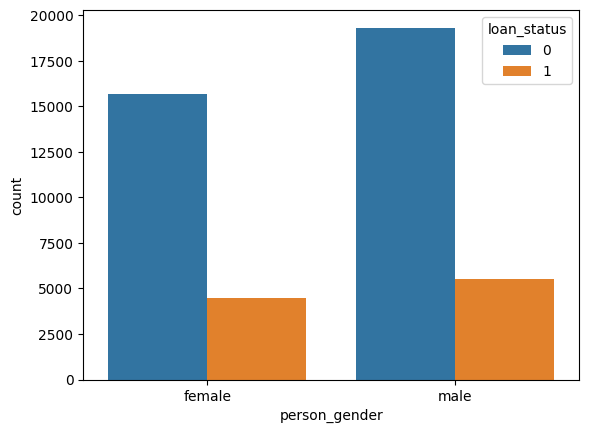

In [24]:
# observe which gender getting more loans
sns.countplot(x="person_gender",data=df,hue="loan_status")

<Axes: xlabel='person_age', ylabel='Count'>

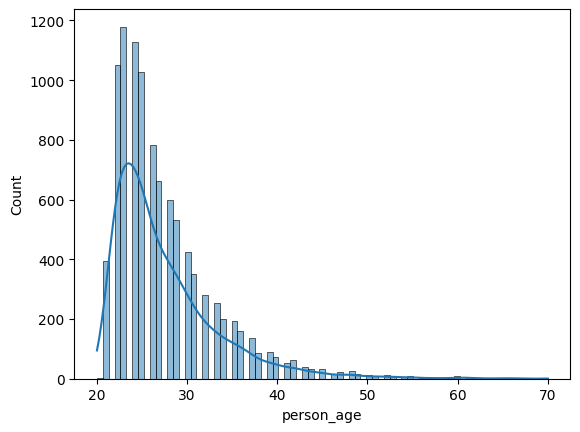

In [31]:
from re import T
# observe data which age group getting more loans
sns.histplot(x="person_age",data=df[df["loan_status"] == 1],kde=True)

<Axes: xlabel='person_education', ylabel='count'>

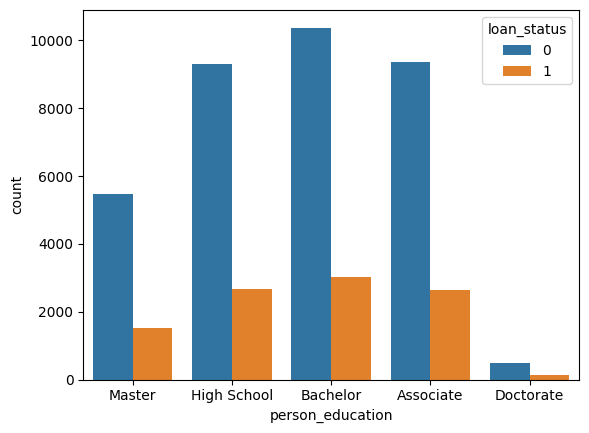

In [34]:
# observe which education background getting  more loans
sns.countplot(x="person_education",data=df,hue="loan_status")

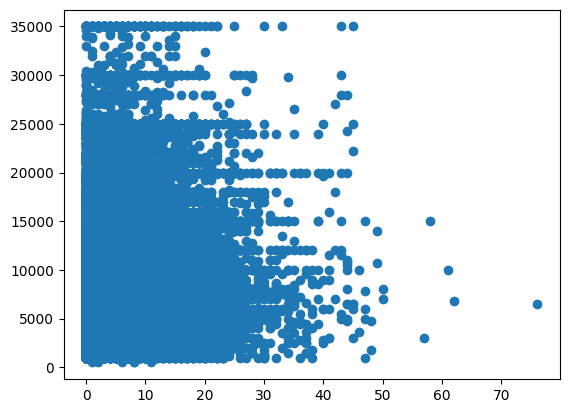

In [37]:
# person_emp_exp and loan_amnt
plt.scatter(df["person_emp_exp"],df["loan_amnt"])

<Axes: xlabel='credit_score', ylabel='Count'>

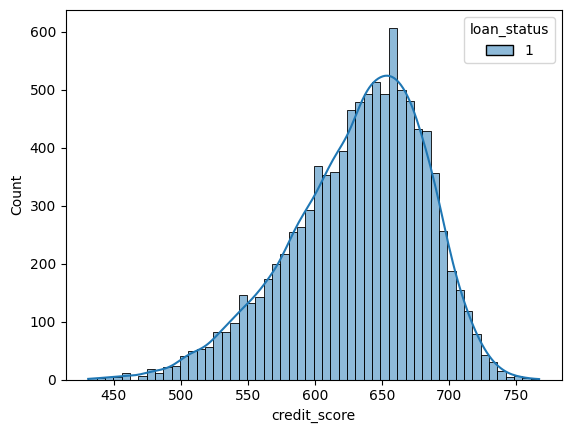

In [39]:
# distribution of credit score
sns.histplot(x="credit_score",data=df[df["loan_status"]==1],kde=True,hue="loan_status")

<Axes: >

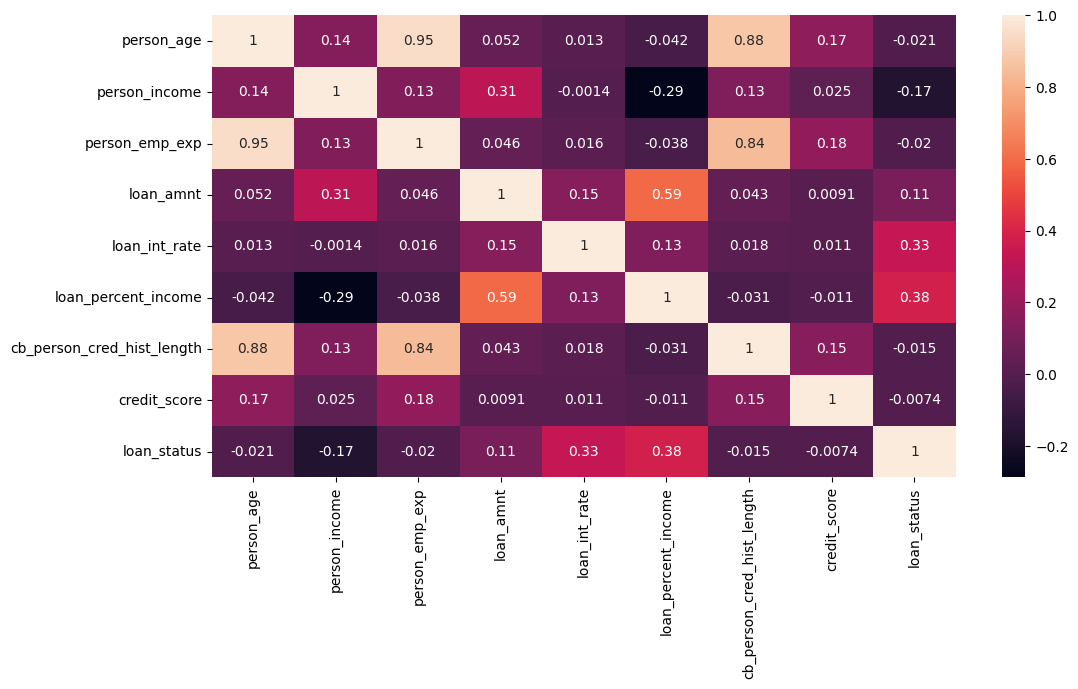

In [42]:
# correlation
# filter all numerical cols
num_cols = [col for col in df.columns if df[col].dtype!=object]
# find correlation between numerical cols
data = df[num_cols].corr()
# increase size of plot
plt.figure(figsize=(12,6))
# plot heatmap
sns.heatmap(data,annot=True)

# Model Training

In [47]:
# Encoding
from sklearn.preprocessing import LabelEncoder

enc = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = enc.fit_transform(df[col])



In [48]:
# divide data into input and output
X = df.drop("loan_status",axis=1)
y = df["loan_status"]

In [49]:
# split the data for training and testing
Xtrain,Xtest,ytrain,ytest = train_test_split(X,y,test_size=0.3,random_state=42)

In [57]:
# scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
Xtrain = scaler.fit_transform(Xtrain)
Xtest = scaler.transform(Xtest)

In [58]:
# model training
model = SVC()
model.fit(Xtrain,ytrain)

SVC()

# Prediction

In [59]:
# model prediction
ypred = model.predict(Xtest)
ypred

array([1, 0, 0, ..., 1, 0, 1])

In [60]:
# printing confusion matrix
confusion_matrix(ytest,ypred)

array([[10044,   446],
       [  792,  2216]])

In [61]:
# printing classification report
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.93      0.96      0.94     10490
           1       0.83      0.74      0.78      3008

    accuracy                           0.91     13498
   macro avg       0.88      0.85      0.86     13498
weighted avg       0.91      0.91      0.91     13498



In [62]:
# finding efficiency
print("Training Eff: ",model.score(Xtrain,ytrain))
print("Testing Eff: ",model.score(Xtest,ytest))

Training Eff:  0.9132560723924432
Testing Eff:  0.9082827085494147


without scaling it is giving --> 80% eff

with scaling --> 90% eff

In [64]:
# New input prediction
new_data = df.iloc[0:1,:-1]
new_data = scaler.transform(new_data) #because the new data is taking unscaled data so do scaling
pred = model.predict(new_data)[0]
if pred == 0:
  print("Loan Not Approved")
else:
  print("Loan Approved")

Loan Approved
